In [10]:
# Group by the discount column and calculate the mean quantity
discount_comparison = df.groupby('Discount Applied')['Quantity'].mean().reset_index()

print(discount_comparison)


   Discount Applied  Quantity
0             False  5.537852
1              True  5.533466


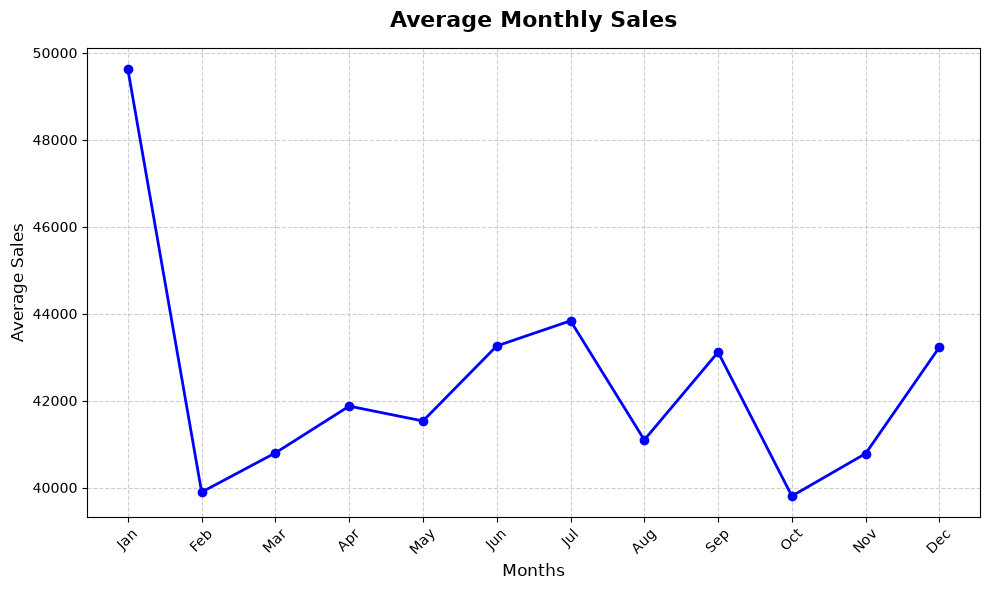

In [17]:
#Visualising Average Monthly Sales

import matplotlib.pyplot as plt 

plt.figure(figsize=(10, 6)) 

plt.plot(monthly_avg_sales['Month'], monthly_avg_sales['Avg Monthly Sales'], marker='o', color='b', linewidth=2) 

plt.xticks(
    ticks=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], 
    labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
    rotation=45
)

plt.title('Average Monthly Sales', fontsize=16, fontweight='bold', pad=15); plt.ylabel('Average Sales', fontsize=12); plt.xlabel('Months', fontsize=12) 

plt.grid(True, linestyle='--', alpha=0.6) 

plt.tight_layout() 

plt.show()




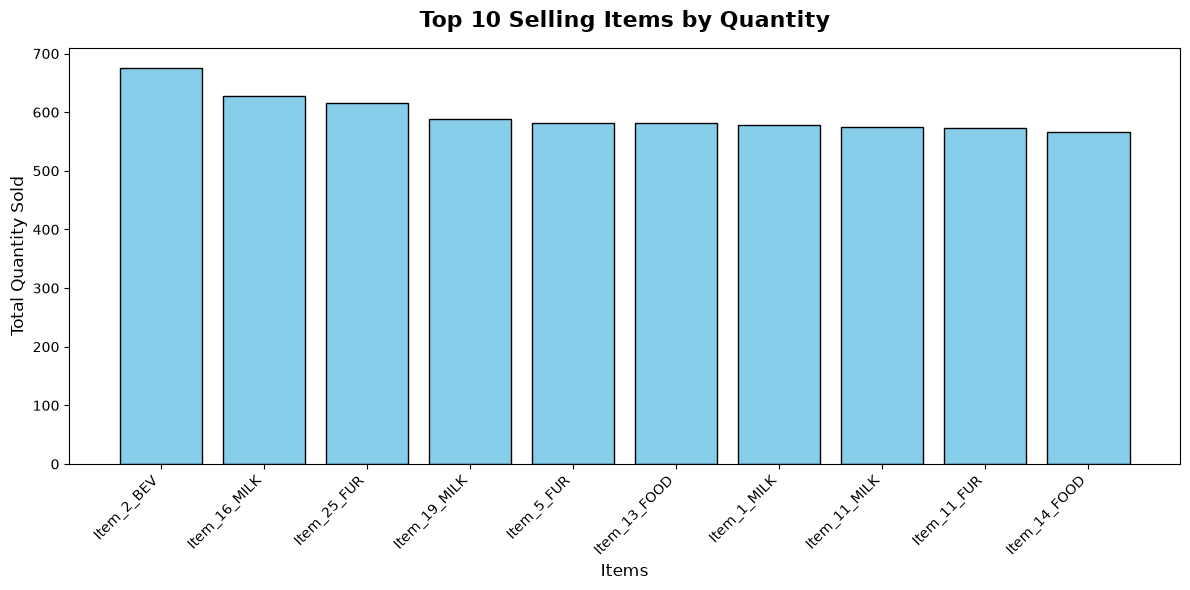

In [18]:
#Visualising top 10 selling items
top_10_items = item_totals.head(10)
plt.figure(figsize=(12, 6))
plt.bar(top_10_items['Item'], top_10_items['Quantity'], color='skyblue', edgecolor='black')
plt.title('Top 10 Selling Items by Quantity', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Items', fontsize=12)
plt.ylabel('Total Quantity Sold', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

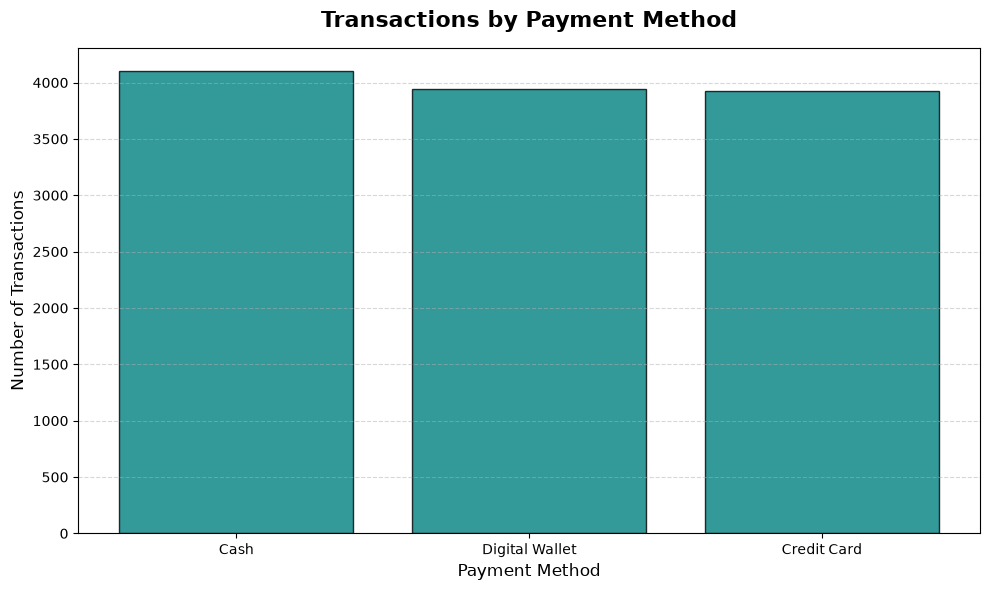

In [19]:
#Visualising the Payment Method by the number of transactions
plt.figure(figsize=(10, 6))

plt.bar(payment_counts['Payment Method'], payment_counts['Payment Count'], color='teal', edgecolor='black', alpha=0.8)

plt.title('Transactions by Payment Method', fontsize=16, fontweight='bold', pad=15); plt.xlabel('Payment Method', fontsize=12); plt.ylabel('Number of Transactions', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.5)  # Adds horizontal gridlines only

plt.tight_layout()

plt.show()




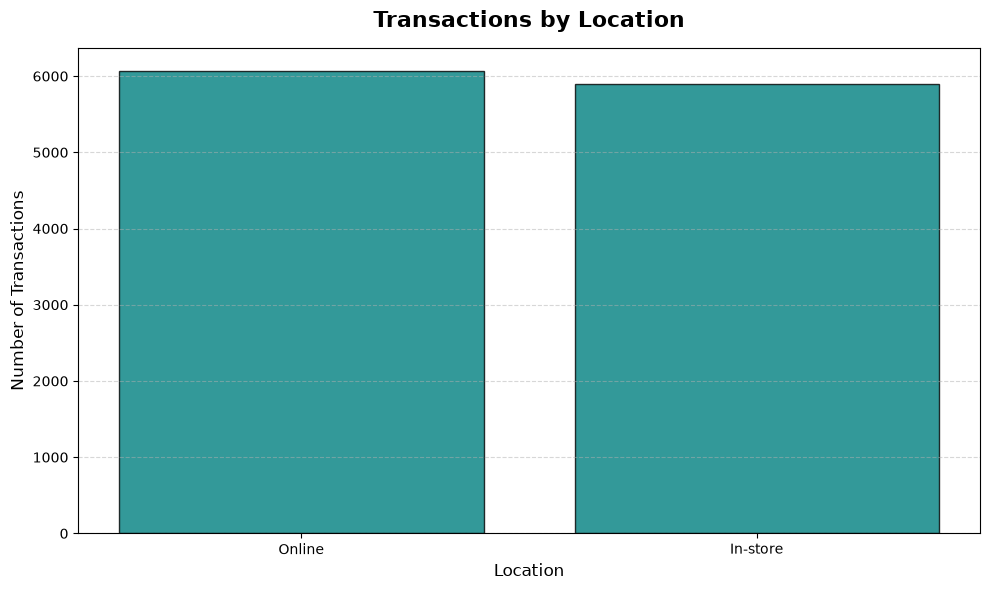

In [20]:
#Visualising the Payment Method
plt.figure(figsize=(10, 6))
plt.bar(location_count['Location'], location_count['Location Count'], color='teal', edgecolor='black', alpha=0.8)
plt.title('Transactions by Location', fontsize=16, fontweight='bold', pad=15); plt.xlabel('Location', fontsize=12); plt.ylabel('Number of Transactions', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)  
plt.tight_layout()
plt.show()

In [21]:
# Creating a Python Dictionary
import calendar
import pprint

top_item_row = item_totals.iloc[0]
top_item_name = top_item_row['Item']
top_item_qty = int(top_item_row['Quantity']) 

yearly_totals = df.groupby('Year')['Total Spent'].sum()
yearly_rev_dict = {int(year): round(float(val), 2) for year, val in yearly_totals.items()}

peak_month_row = monthly_avg_sales.sort_values(by='Avg Monthly Sales', ascending=False).iloc[0]

peak_month_name = calendar.month_name[int(peak_month_row['Month'])]

peak_month_total = round(float(peak_month_row['Avg Monthly Sales']), 2)

packaged_data = {
    "top_item": {
        "name": top_item_name,
        "quantity": top_item_qty
    },
    "yearly_revenue": yearly_rev_dict,
    "peak_perfomance": {
        "month": peak_month_name,
        "revenue": peak_month_total
    }
}

pprint.pprint(packaged_data)


{'peak_perfomance': {'month': 'January', 'revenue': 49624.17},
 'top_item': {'name': 'Item_2_BEV', 'quantity': 676},
 'yearly_revenue': {2022: 510329.5, 2023: 491312.0, 2024: 524881.0}}


In [22]:
# Creating a Python Dictionary
import calendar
import pprint

top_item_row = item_totals.iloc[0]
top_item_name = top_item_row['Item']
top_item_qty = int(top_item_row['Quantity']) 

yearly_totals = df.groupby('Year')['Total Spent'].sum()
yearly_rev_dict = {int(year): round(float(val), 2) for year, val in yearly_totals.items()}

peak_month_row = monthly_avg_sales.sort_values(by='Avg Monthly Sales', ascending=False).iloc[0]

peak_month_name = calendar.month_name[int(peak_month_row['Month'])]

peak_month_total = round(float(peak_month_row['Avg Monthly Sales']), 2)

packaged_data = {
    "top_item": {
        "name": top_item_name,
        "quantity": top_item_qty
    },
    "yearly_revenue": yearly_rev_dict,
    "peak_perfomance": {
        "month": peak_month_name,
        "revenue": peak_month_total
    }
}

pprint.pprint(packaged_data)


{'peak_perfomance': {'month': 'January', 'revenue': 49624.17},
 'top_item': {'name': 'Item_2_BEV', 'quantity': 676},
 'yearly_revenue': {2022: 510329.5, 2023: 491312.0, 2024: 524881.0}}


In [23]:
import os
print(os.environ.get('OPENAI_API_KEY') is not None)

True


In [24]:
!pip install openai

Defaulting to user installation because normal site-packages is not writeable


In [25]:
from openai import OpenAI

client = OpenAI()

In [26]:
import json
data_json = json.dumps(packaged_data)

prompt = f"""
Only use the exact numbers provided below. Do not calculate, estimate, or infer any additional figures. Your job is to write a clear, professional narrative explaining what these numbers mean for the business. Only narrate what the numbers reveal instead of jumping in the why they do so. Your job is to focus on what happened not why it happened. All numbers provided are actual historical facts, not projections, forecasts, or estimates — treat 2022, 2023, and 2024 as equally real, completed years. Do not use words like 'projected,' 'anticipated,' or 'estimated' unless explicitly told a figure is a forecast. Avoid adding speculative explanations for trends at all.
Data:
{data_json}
"""

response = client.chat.completions.create(
    model="gpt-4o-mini",
    max_tokens=500,
    messages=[
        {"role": "user", "content": prompt}
    ]
)
print(response.choices[0].message.content)

The provided data outlines the business performance across three consecutive years, focusing on revenue figures and a specific top item sold during this period. 

In 2022, the total revenue was $510,329.50, which slightly decreased to $491,312.00 in 2023. However, in 2024, there was an increase in revenue, reaching $524,881.00. This pattern indicates a decline from 2022 to 2023, followed by a recovery and growth in 2024.

The top item sold during this time was "Item_2_BEV," with a total quantity sold of 676 units. This figure highlights the item’s contribution to the overall business performance.

Additionally, January was noted as the peak performance month, generating revenue of $49,624.17. This peak demonstrates a significant revenue occasion within the context of the annual figures.

Overall, the data illustrates a dynamic revenue trend over the three years and emphasizes the importance of "Item_2_BEV" in the business’s sales mix.


In [34]:
df.to_csv('cleaned_retail_sales.csv', index=False)

In [35]:
df.isnull().sum()
df.shape

(11769, 13)

In [30]:
df[['Price Per Unit', 'Quantity', 'Total Spent']].describe()

,Price Per Unit,Quantity,Total Spent
count,11769.000000,11769.000000,11769.000000
mean,23.351644,5.538788,129.707069
std,10.741875,2.857934,94.807623
min,5.000000,1.000000,5.000000
25%,14.000000,3.000000,51.000000
50%,23.000000,6.000000,108.500000
75%,33.500000,8.000000,192.000000
max,41.000000,10.000000,410.000000


In [31]:
df[['Price Per Unit', 'Quantity', 'Total Spent']].isnull().sum(axis=1).max()

np.int64(0)

In [36]:
df = pd.read_csv('retail_store_sales.csv')
print(df.shape)


(12575, 11)


In [37]:
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], format='%Y-%m-%d', errors='coerce')
df['Discount Applied'] = df['Discount Applied'].fillna(False).astype(bool)
missing_count = df[['Price Per Unit', 'Quantity', 'Total Spent']].isnull().sum(axis=1)
print((missing_count == 1).sum(), (missing_count >= 2).sum())

609 604


In [38]:
df = df[missing_count < 2]
print(df.shape)


(11971, 11)


In [39]:
df.loc[df['Total Spent'].isnull(), 'Total Spent'] = df['Price Per Unit'] * df['Quantity']
df.loc[df['Price Per Unit'].isnull(), 'Price Per Unit'] = df['Total Spent'] / df['Quantity']
df.loc[df['Quantity'].isnull(), 'Quantity'] = df['Total Spent'] / df['Price Per Unit']
print(df[['Total Spent', 'Price Per Unit', 'Quantity']].isnull().sum())
print(df.shape)

Total Spent       0
Price Per Unit    0
Quantity          0
dtype: int64
(11971, 11)


In [40]:
df['Item'] = df['Item'].fillna('Unknown')
print(df.isnull().sum())
print(df.shape)

Transaction ID      0
Customer ID         0
Category            0
Item                0
Price Per Unit      0
Quantity            0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
Discount Applied    0
dtype: int64
(11971, 11)


In [41]:
df['Year'] = df['Transaction Date'].dt.year
df['Month'] = df['Transaction Date'].dt.month
print(df.shape)
print(df['Year'].value_counts())

(11971, 13)
Year
2024    4036
2022    3925
2023    3808
2025     202
Name: count, dtype: int64


In [42]:
df = df[df['Year'] != 2025]
print(df.shape)
df.to_csv('cleaned_retail_sales_v2.csv', index=False)

(11769, 13)


In [44]:
"""
Retail Sales Analysis and AI Reporting Pipeline
=================================================

Cleans a raw retail POS export, answers four core business questions plus a
seasonality analysis, generates four supporting charts, and produces an
AI-written executive summary from the computed results.

Design principle: all math (sums, averages, comparisons) is done in pandas,
never by the AI. The AI is only used to turn already-verified numbers into
readable language. See the accompanying case study for the reasoning behind
each decision below, including the bugs hit along the way.
"""

import pandas as pd
import matplotlib.pyplot as plt
import calendar
import json
import os
from openai import OpenAI


# ---------------------------------------------------------------------------
# 1. LOAD
# ---------------------------------------------------------------------------

df = pd.read_csv('retail_store_sales.csv')
# Expected shape at this point: (12575, 11)


# ---------------------------------------------------------------------------
# 2. CLEAN
# ---------------------------------------------------------------------------

# Raw dates are stored as YYYY-M-D in the source file. An earlier attempt
# used %m/%d/%Y based on how the dates displayed in Excel -- Excel silently
# reformats how dates are shown without changing the underlying data, so
# that format matched nothing and silently converted every date to NaT.
# Always verify raw values in a plain text editor, not a spreadsheet UI.
df['Transaction Date'] = pd.to_datetime(
    df['Transaction Date'], format='%Y-%m-%d', errors='coerce'
)

# Discount Applied: missing values default to False (not discounted).
# A missing flag on a low-stakes categorical field is a safer assumption
# than fabricating a financial figure would be.
df['Discount Applied'] = df['Discount Applied'].fillna(False).astype(bool)

# Price Per Unit / Quantity / Total Spent are mathematically related:
#   Total Spent = Price Per Unit * Quantity
# A row missing exactly ONE of the three is recoverable by rearranging the
# formula. A row missing two or more has no way to reconstruct the third,
# so only those rows are dropped.
missing_count = df[['Price Per Unit', 'Quantity', 'Total Spent']].isnull().sum(axis=1)
df = df[missing_count < 2]  # drop only the unrecoverable rows

# Recover the single missing value, wherever exactly one is missing.
# Order is safe here specifically because rows with 2+ missing were already
# dropped above -- these three lines can never compete for the same row.
df.loc[df['Total Spent'].isnull(), 'Total Spent'] = df['Price Per Unit'] * df['Quantity']
df.loc[df['Price Per Unit'].isnull(), 'Price Per Unit'] = df['Total Spent'] / df['Quantity']
df.loc[df['Quantity'].isnull(), 'Quantity'] = df['Total Spent'] / df['Price Per Unit']

# Item: missing values labeled "Unknown" rather than guessed. A category +
# price match was considered and rejected -- multiple items can share both,
# so any guess would be unverifiable. An honest "Unknown" costs little; an
# unverifiable guess risks silently corrupting the analysis.
df['Item'] = df['Item'].fillna('Unknown')

# Sanity check: everything should be clean at this point.
assert df.isnull().sum().sum() == 0, "Unexpected missing values remain after cleaning"


# ---------------------------------------------------------------------------
# 3. TIME FIELDS
# ---------------------------------------------------------------------------

df['Year'] = df['Transaction Date'].dt.year
df['Month'] = df['Transaction Date'].dt.month

# 2025 is a partial year (202 rows -- confirmed via value_counts(), not
# assumed from a single sample date). Comparing a partial year against full
# years would create a misleading artificial drop, so it's excluded from
# any year-based or seasonal analysis.
df = df[df['Year'] != 2025]

df.to_csv('cleaned_retail_sales.csv', index=False)


# ---------------------------------------------------------------------------
# 4. ANALYSIS
# ---------------------------------------------------------------------------

# --- Q1: Most sold item, by unit volume ---
# Volume (not revenue, not transaction count) answers "what should we stock
# more of" without being skewed by a few high-price items or bulk orders.
# "Unknown" items are excluded from this specific ranking since they carry
# no real product identity.
item_totals = (
    df[df['Item'] != 'Unknown']
    .groupby('Item')['Quantity'].sum()
    .reset_index()
    .sort_values(by='Quantity', ascending=False)
    .reset_index(drop=True)
)
top_item_row = item_totals.iloc[0]

# --- Q2: Does a discount correlate with a larger purchase? ---
# Average (not total) controls for the two groups having different sizes.
discount_comparison = df.groupby('Discount Applied')['Quantity'].mean().reset_index()

# Follow-up: discount rate by category (rate = mean of a boolean column,
# since True/False behave as 1/0 in Python).
category_discounts = (
    df.groupby('Category')['Discount Applied'].mean()
    .reset_index()
    .rename(columns={'Discount Applied': 'Discount Rate'})
    .sort_values(by='Discount Rate', ascending=False)
    .reset_index(drop=True)
)

# --- Q3: Preferred payment method ---
payment_counts = (
    df.groupby('Payment Method').size()
    .reset_index(name='Transaction Count')
    .sort_values(by='Transaction Count', ascending=False)
    .reset_index(drop=True)
)

# --- Q4: Online vs in-store ---
location_counts = (
    df.groupby('Location').size()
    .reset_index(name='Transaction Count')
    .sort_values(by='Transaction Count', ascending=False)
    .reset_index(drop=True)
)

# --- Yearly revenue trend ---
yearly_sales = (
    df.groupby('Year')['Total Spent'].sum()
    .reset_index()
    .sort_values(by='Year')
    .reset_index(drop=True)
)

# --- Seasonality: average monthly revenue, collapsed across years ---
# Two-step aggregation is required: first sum revenue per (Year, Month)
# combination, THEN average those sums across years per calendar month.
# A single-step "average Total Spent by Month" instead averages every
# individual transaction amount, which answers a different question
# (typical transaction size) rather than typical monthly revenue.
monthly_totals = (
    df.groupby(['Year', 'Month'])['Total Spent'].sum()
    .reset_index()
    .sort_values(by=['Year', 'Month'])
    .reset_index(drop=True)
)
monthly_avg_sales = (
    monthly_totals.groupby('Month')['Total Spent'].mean()
    .reset_index()
    .rename(columns={'Total Spent': 'Avg Monthly Sales'})
)
monthly_avg_sales['Avg Monthly Sales'] = monthly_avg_sales['Avg Monthly Sales'].round(2)

peak_month_row = monthly_avg_sales.sort_values(by='Avg Monthly Sales', ascending=False).iloc[0]

# Validation: the peak month should be high in EACH individual year, not
# just on the blended average -- otherwise one strong year could be
# masquerading as a genuine seasonal pattern.
peak_month_by_year = monthly_totals[monthly_totals['Month'] == peak_month_row['Month']]


# ---------------------------------------------------------------------------
# 5. CHARTS
# ---------------------------------------------------------------------------

# Seasonality: a line chart, since months have a natural order and the
# shape of the trend across time is the point.
plt.figure(figsize=(10, 6))
plt.plot(monthly_avg_sales['Month'], monthly_avg_sales['Avg Monthly Sales'],
          marker='o', color='b', linewidth=2)
plt.xticks(
    ticks=list(range(1, 13)),
    labels=[calendar.month_abbr[m] for m in range(1, 13)],
    rotation=45
)
plt.title('Average Monthly Sales', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('Average Sales ($)', fontsize=12)
plt.xlabel('Month', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('chart_seasonality.png')
plt.close()

# Top 10 items: a sorted bar chart, not a pie chart -- a pie chart implies
# the slices sum to 100% of everything, which a top-10-of-200 subset does
# not represent.
top_10_items = item_totals.head(10)
plt.figure(figsize=(12, 6))
plt.bar(top_10_items['Item'], top_10_items['Quantity'], color='skyblue', edgecolor='black')
plt.title('Top 10 Selling Items by Quantity', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Item', fontsize=12)
plt.ylabel('Total Quantity Sold', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('chart_top_items.png')
plt.close()

# Payment method comparison
plt.figure(figsize=(10, 6))
plt.bar(payment_counts['Payment Method'], payment_counts['Transaction Count'],
        color='teal', edgecolor='black', alpha=0.8)
plt.title('Transactions by Payment Method', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Payment Method', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('chart_payment_method.png')
plt.close()

# Location comparison
plt.figure(figsize=(10, 6))
plt.bar(location_counts['Location'], location_counts['Transaction Count'],
        color='teal', edgecolor='black', alpha=0.8)
plt.title('Transactions by Location', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Location', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('chart_location.png')
plt.close()


# ---------------------------------------------------------------------------
# 6. AI SUMMARY
# ---------------------------------------------------------------------------
# Only pre-computed, verified numbers are sent to the model -- never raw
# transaction data. This removes any risk of the AI "calculating" by
# pattern-matching rather than doing real arithmetic.

packaged_data = {
    "top_item": {
        "name": top_item_row['Item'],
        "quantity": int(top_item_row['Quantity'])
    },
    "yearly_revenue": {
        int(row['Year']): round(float(row['Total Spent']), 2)
        for _, row in yearly_sales.iterrows()
    },
    "peak_performance": {
        "month": calendar.month_name[int(peak_month_row['Month'])],
        "revenue": round(float(peak_month_row['Avg Monthly Sales']), 2)
    }
}
data_json = json.dumps(packaged_data)

# This exact wording is the result of five rounds of testing against real
# model output -- earlier, looser versions let the AI label a real
# historical year as "projected," invent causal explanations for trends,
# and generalize a single month's peak into a vague seasonal claim about
# "the beginning of the year." See the case study for the full iteration
# history.
prompt = f"""
Only use the exact numbers provided below. Do not calculate, estimate, or
infer any additional figures. All numbers provided are actual historical
facts, not projections, forecasts, or estimates. Do not use words like
'projected,' 'anticipated,' or 'estimated.' Avoid adding speculative
explanations or general conclusions for trends at all. Be specific about
what the data reveals and never generalize any outcome beyond what was
measured.

Data:
{data_json}
"""

client = OpenAI()  # reads OPENAI_API_KEY from environment

response = client.chat.completions.create(
    model="gpt-4o-mini",
    max_tokens=500,
    messages=[{"role": "user", "content": prompt}]
)

print(response.choices[0].message.content)

The top item is "Item_2_BEV" with a quantity of 670. The yearly revenue for the years provided is as follows: in 2022, the revenue was 510,329.5; in 2023, it was 491,312.0; and in 2024, it is 524,881.0. The peak performance occurred in January, with a revenue of 49,624.17.
